<div align="left" style="background-color: #008080; padding: 20px 10px;">
<h3><b>IDEAS - Institute of Data Engineering, Analytics and Science Foundation</b></h3>
<p>Summer Internship Program 2026</p>
<hr style="width:100%;">
<h3><b>Project Title:</b> Diabetes Prediction: Classification Comparison + Metrics + Evaluation</h3>
<h4>Project Notebook</h4>

<blockquote style="border-left: 4px solid #4285F4; padding-left: 15px;">
  <strong>Created by:</strong> Rounak Biswas<br>
  <strong>Designation:</strong> Software Engineer
</blockquote>
<hr style="width:100%;">
</div>

##  Problem Statement

You are tasked with building a classification model to predict whether a patient has diabetes based on diagnostic measurements.

- Use the **Pima Indian Diabetes Dataset**.
- Compare multiple classification models.
- Evaluate them using accuracy, precision, recall, F1-score, ROC-AUC.


---


##  Dataset Introduction

The dataset contains medical predictor variables and one target variable (`Outcome`).

- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome (0 = No Diabetes, 1 = Diabetes)

### Question 1: Import Libraries and Load Data (2 Marks)

Import `pandas` as `pd` and `numpy` as `np`. Load the Pima Indian Diabetes Dataset `diabetes.csv` from https://drive.google.com/drive/folders/1gieHICVDBbUKMZiSF4YRQMAJic-w50JM?usp=sharing into a pandas DataFrame called `df`. Display the first 5 rows of the DataFrame.

**Expected Output:** A table showing the first 5 rows of the diabetes dataset.

In [72]:
import numpy as np
import pandas as pd
df = pd.read_csv('diabetes.csv')
print("The first 5 rows of the diabetes dataset:")
df.head()

The first 5 rows of the diabetes dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Question 2: Data Inspection (2 Marks)

Get a quick overview of the dataset. Print the shape of the DataFrame and then check for the total number of missing (null) values across the entire DataFrame.

**Expected Output:** The shape of the DataFrame (e.g., `(768, 9)`) and the total count of null values.

In [73]:
print("the shape of the dataframe: ",df.shape)
total=df.isna().sum().sum()
print("the total number of missing values across the entire dataframe: ",total)

the shape of the dataframe:  (768, 9)
the total number of missing values across the entire dataframe:  0


### Question 3: Descriptive Statistics (1 Mark)

Generate the descriptive statistics for the `df` DataFrame to understand the central tendency, dispersion, and shape of the dataset's distribution.

**Hint:** Use the `.describe()` method on the DataFrame.

**Expected Output:** A table showing statistical details like mean, std, min, max, etc., for each numerical column.

The descriptive statistics for the df DataFrame:

central tendancy and dispersion of the dataframe
                           count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.24375   
Age                       768.0   33.240885   11.760232  21.000  24.00000   
Outcome                   768.0    0.348958    0.476951   0.000   0.00000   

                               50%        75%     max  
Pregnancies                 3.0000    6.00000   17.00  
Glucose          

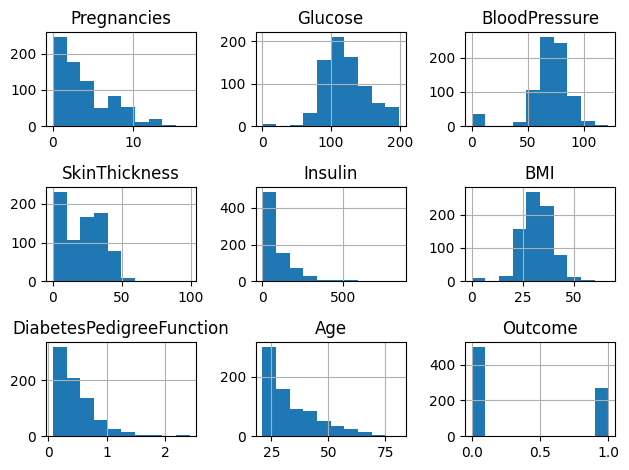

In [74]:
import matplotlib.pyplot as plt
stats=df.describe().T
print("The descriptive statistics for the df DataFrame:\n")
print("central tendancy and dispersion of the dataframe\n",stats)
print("\n")
print("shape of the datasets distribution:")
df.hist()
plt.tight_layout()
plt.show()

### Question 4: Define Feature Matrix and Target Vector (2 Marks)

Prepare the data for modeling by separating it into features (`X`) and the target (`y`). `X` should contain all columns except 'Outcome', and `y` should be the 'Outcome' column. Print the shapes of both `X` and `y`.

**Expected Output:** The shapes of `X` and `y`, which should be `(768, 8)` and `(768,)`.

In [75]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print("the shape of X: ",X.shape)
print("the shape of y: ",y.shape)

the shape of X:  (768, 8)
the shape of y:  (768,)


### Question 5: Split Data into Training and Testing Sets (2 Marks)

Import `train_test_split` from `sklearn.model_selection`. Split the `X` and `y` data into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`). Use `test_size=0.2`, `random_state=42`, and enable stratification on `y`.

**Expected Output:** No direct output. The variables will be ready for the next steps.

In [76]:
from sklearn.model_selection import train_test_split
'''splitting X(variables) and y(output) into training and testing data's for classification and taking 20% of data
   for testing and 80% for training and random state ensures your split is the same every time you run the code(42 as given)
   and finally stratify on y ensures class proportions are preserved in both train and test sets'''
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



### Question 6: Scale the Feature Data (3 Marks)

Import `StandardScaler` from `sklearn.preprocessing`. Create an instance of the scaler, fit it on the training data (`X_train`), and then transform both `X_train` and `X_test`. Store the results in `X_train_scaled` and `X_test_scaled`.

**Expected Output:** No direct output. The scaled data will be stored in new variables.

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Question 7: Train and Evaluate a Logistic Regression Model (5 Marks)

Import `LogisticRegression`. Create an instance, train it on the **scaled** training data (`X_train_scaled`, `y_train`), make predictions on the scaled test data, and print the `classification_report`.

**Expected Output:** A text-based classification report showing precision, recall, and f1-score for classes 0 and 1.

In [78]:
#create a logistic regression model.fit the data in the model.
#We are training the model and asking to predict output and evaluate the model from its classification_report(precision recall f1-score and support).

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
log_reg  = LogisticRegression()
log_reg .fit(X_train_scaled, y_train)
y_pred = log_reg .predict(X_test_scaled)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



### Question 8: Train and Evaluate a K-Nearest Neighbors (KNN) Model (5 Marks)

Import `KNeighborsClassifier`. Create an instance with `n_neighbors=5`, train it on the scaled training data, make predictions on the scaled test data, and print the `accuracy_score`.

**Expected Output:** A single decimal number representing the accuracy of the KNN model.

In [79]:
#create a KNN model.fit the data in the model.
#We are training the model and asking to predict output and evaluate the model from its accuracy score.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7012987012987013


### Question 9: Train and Evaluate a Support Vector Machine (SVM) Model (5 Marks)

Import `SVC` (Support Vector Classifier). Create an instance with a `kernel='linear'` and `random_state=42`. Train it on the scaled training data, predict on the scaled test data, and print the `f1_score`.

**Expected Output:** A single decimal number representing the F1-score of the SVM model.

In [80]:
#create a SVC model.fit the data in model.
#we are training the model and asking to predict output and evaluate teh model from its f1-score.

from sklearn.svm import SVC
from sklearn.metrics import f1_score
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
f1 = f1_score(y_test, y_pred)
print(f1)

0.5656565656565656


### Question 10: Model Comparison with ROC-AUC Score (3 Marks)

Calculate the `roc_auc_score` for all three models (Logistic Regression, KNN, and SVM) using their predictions on the scaled test data. Store the results in a dictionary called `model_scores` where keys are model names ('LogisticRegression', 'KNN', 'SVM') and values are their scores. Print the dictionary. Which model performed best?

**Hint:** Import `roc_auc_score` from `sklearn.metrics`. This score measures a model's ability to distinguish between classes. You will need the predictions you generated in the previous steps.

**Expected Output:** A dictionary showing the name of each model and its corresponding ROC-AUC score. A simple conclusion of which model performed best on performance.

In [81]:
'''Model comparision (logistic_regression, KNN and SVM)
   store predicted values of each model and create a dictionary with the model name
   and its corresponding ROC-AUC scores and evaluate the best model. '''
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

log_pred = log_reg.predict(X_test_scaled)
knn_pred = knn.predict(X_test_scaled)
svm_pred = svm.predict(X_test_scaled)

model_scores = {
    'LogisticRegression': roc_auc_score(y_test, log_pred),
    'KNN': roc_auc_score(y_test, knn_pred),
    'SVM': roc_auc_score(y_test, svm_pred)
}

best_model = max(model_scores)
print(model_scores)
print("Best Model:", best_model)

{'LogisticRegression': np.float64(0.6692592592592593), 'KNN': np.float64(0.6592592592592593), 'SVM': np.float64(0.6742592592592592)}
Best Model: SVM
